# Enriched SAE features
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rotskoff-group/idiom/blob/v1.0.0/cookbook/notebooks/enriched_sae_features.ipynb)

Compare positive IDRs with a length-matched background and export enriched feature IDs for the SAE reward notebook.


## Setup
A GPU runtime is recommended: **Runtime → Change runtime type → GPU**. CPU execution is supported but slower.

Run cells in order. Installation is self-contained; no repository clone or account is needed. If Colab requests a session restart after installation, restart before running the imports. The first model load downloads weights.


In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("idiom") is None:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "idiom @ git+https://github.com/rotskoff-group/idiom.git@v1.0.0",
    ])


In [2]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

from idiom import IDiomSAE
from idiom.data.records import read_records
from idiom.utils.notebook_helpers import example_file, idr_sequence, isolated, save_run
from huggingface_hub import hf_hub_download

started = time.perf_counter()


## Settings


In [3]:
SAE_ID = "jxliu2/idiomsae-300M-L18-k32" # Pretrained SAE and its frozen host model
DEVICE = "auto" # "cpu" or "cuda"; "auto" uses an available GPU
MAX_BACKGROUND = 10000 # Maximum length-matched background IDRs
BATCH_SIZE = 2 # Sequences per SAE encoding batch
SEED = 0 # Random seed
TOP_N = 30 # Maximum features to include after filtering
NAME = "nucleolus" # Signature name to use as SIGNATURE_NAME in the SAE reward notebook
CASE = "top30" # Signature group to use as CASE in the SAE reward notebook
OUT_DIR = Path("enrichment_outputs") / time.strftime("%Y%m%d-%H%M%S") # New timestamped folder per run

## Prepare sequences
Use the complete nucleolus IDR set as positives and a length-matched sample of 10,000 IDRs from IDiom-DB validation as background. The validation FASTA downloads once and is cached locally.

Keep unique IDRs within the SAE host's context limit and exclude exact positive/background overlaps. Length matching does not control homology or composition. This validation-based example can select different features from the [paper](https://arxiv.org/abs/2610.02189)'s training-background analysis.


In [4]:
from idiom.sae.features import FeatureDataset, enrich, feature_counts, save_enrichment, select_features, write_signature
from idiom.sae.features.enrichment import length_match, prepare_sequences

OUT_DIR.mkdir(parents=True, exist_ok=True)
positive_path = example_file("protgps/idrs/nucleolus_idrs.fasta", Path("example_inputs"))
background_path = hf_hub_download(
    repo_id="jxliu2/idiom-db", repo_type="dataset",
    filename="idiom-db/idiom-db-v1_validation.fasta",
)
sae = IDiomSAE.from_pretrained(SAE_ID, device=DEVICE)
max_length = sae.model.cfg.max_seq_len - 4
positives, _ = prepare_sequences(isolated(list(read_records(positive_path))), max_length=max_length)
background_pool, _ = prepare_sequences(isolated(list(read_records(background_path))), max_length=max_length)
positive_sequences = {idr_sequence(r) for r in positives}
background_pool = [r for r in background_pool if idr_sequence(r) not in positive_sequences]
background = length_match(positives, background_pool, n=MAX_BACKGROUND, rng=np.random.default_rng(SEED))
if not background:
    raise ValueError("No nonoverlapping background IDRs available.")
print(f"{len(positives)} positive IDRs; {len(background)} background IDRs")


553 positive IDRs; 10000 background IDRs


## Encode and compare
A feature counts once per sequence if it fires anywhere. Selection uses log₂ odds ratios, approximate p-values with Benjamini–Hochberg correction, and the default boundary-artifact filter. A small example may select no features.


In [5]:
pos_fd = FeatureDataset(sae.build_feature_dataset(positives, OUT_DIR / "fd_positive", batch_size=BATCH_SIZE))
bg_fd = FeatureDataset(
    sae.build_feature_dataset(background, OUT_DIR / "fd_background", batch_size=BATCH_SIZE)
)
a, n_pos = feature_counts(pos_fd)
b, n_neg = feature_counts(bg_fd)
result = enrich(a, n_pos, b, n_neg, sae.sae.num_latents)
selection = select_features(result, n=TOP_N, feature_dir=bg_fd)
ids = selection["ids"]
_ = save_enrichment(OUT_DIR / "enrichment.npz", result, selection)

## Inspect and export


In [6]:
table = pd.DataFrame({key: value for key, value in result.items() if isinstance(value, np.ndarray)})
table.insert(0, "feature_id", range(len(table)))
table["selected"] = selection["selected"]
table.to_csv(OUT_DIR / "enrichment.tsv", sep="	", index=False)
columns = ["feature_id", "log2or", "fdr", "prev_pos", "prev_neg", "selected"]
preview = table.loc[table.selected if ids else table.active, columns]
display(preview.sort_values("log2or", ascending=False).head(3))
if ids:
    write_signature(
        OUT_DIR / "signature.json",
        {NAME: ids},
        case=CASE,
        provenance=dict(sae=SAE_ID, seed=SEED, n_pos=n_pos, n_background=n_neg),
    )
    print(f"Signature {NAME!r}: {len(ids)} features (case {CASE!r}); first IDs: {ids[:5]}")
else:
    print("No features passed the filters; no signature was written.")

,feature_id,log2or,fdr,prev_pos,prev_neg,selected
6459,6459,3.197796,4.079167e-88,0.175407,0.0227,True
3270,3270,3.108401,2.825834e-45,0.088608,0.0112,True
2173,2173,3.073387,1.071900e-29,0.057866,0.0073,True


Signature 'nucleolus': 30 features (case 'top30'); first IDs: [6459, 3270, 2173, 3827, 2211]


## Top enriched features
Logos show up to 30 selected features in enrichment order, using up to 80 distinct positive IDRs per feature. Windows span ±7 residues around each sequence’s activation peak. Orange shading shows relative activation strength; the dashed line marks the peak. Fewer panels appear if fewer features pass the filters.


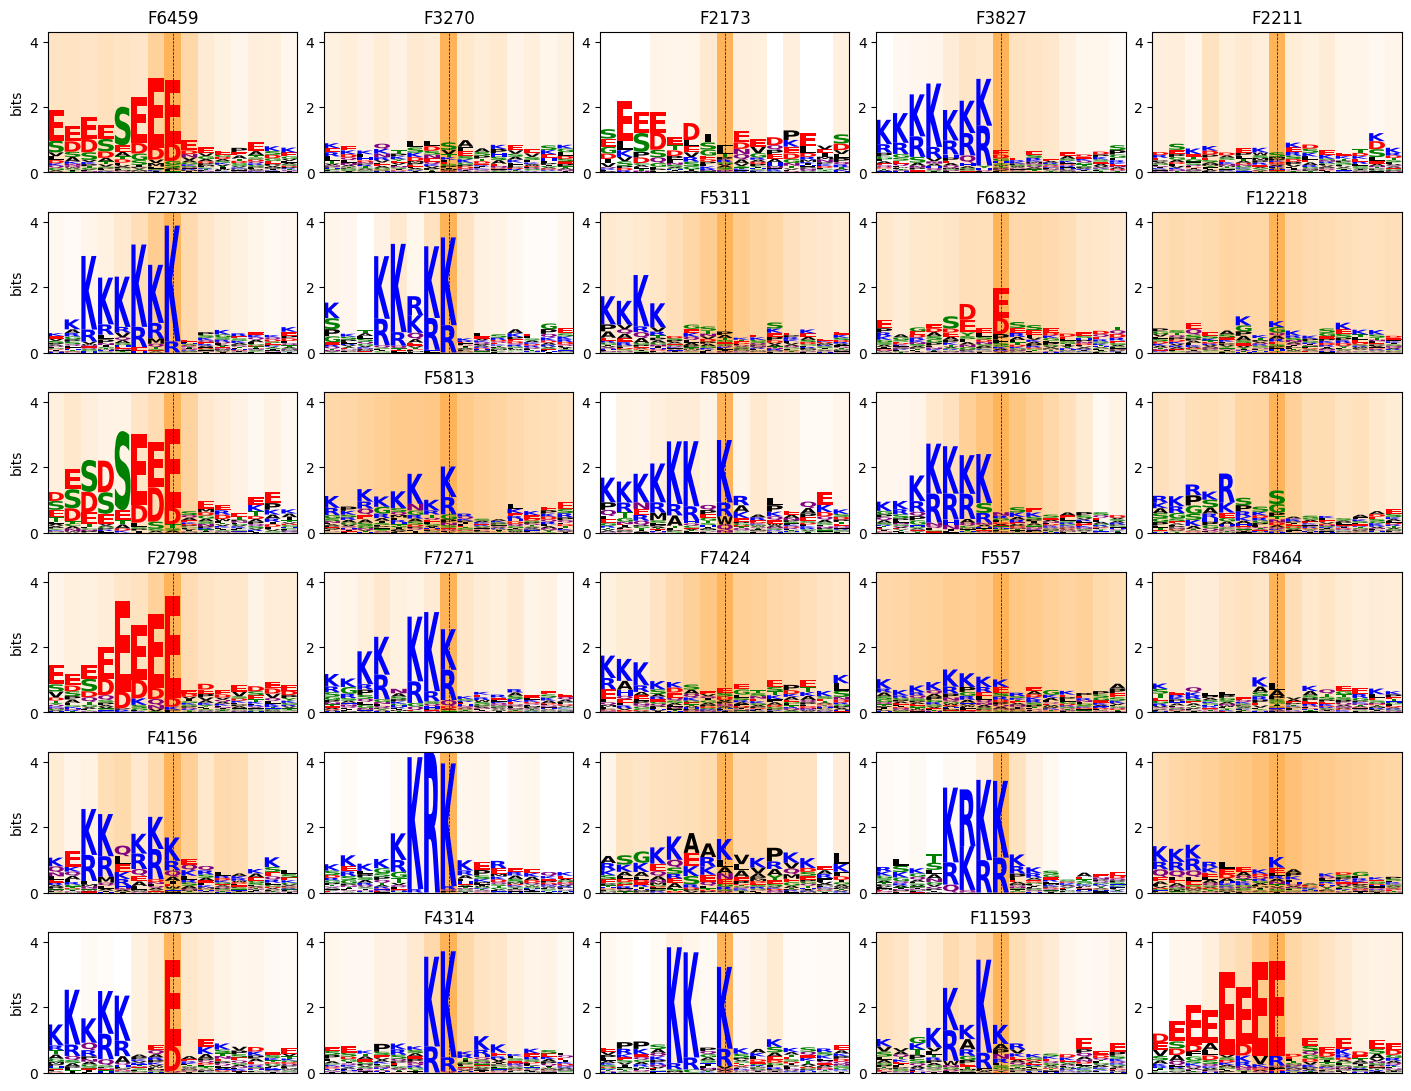

In [7]:
import matplotlib.pyplot as plt
from idiom.utils.notebook_helpers import feature_gallery

gallery = feature_gallery(pos_fd, ids[:30])
if gallery is not None:
    plt.show()


## Results
`enrichment.tsv` and `enrichment.npz` contain the comparison and selection results. `signature.json` is written when features pass the filters. Use that file in [SAE reward design](https://colab.research.google.com/github/rotskoff-group/idiom/blob/v1.0.0/cookbook/notebooks/rl_sae.ipynb), with the same `SAE_ID`, `CASE`, and signature name (`NAME` here becomes `SIGNATURE_NAME` there).

Download results from Colab’s Files pane before the runtime ends.


In [8]:
save_run(
    OUT_DIR,
    dict(
        sae=SAE_ID,
        device=DEVICE,
        seed=SEED,
        positive=str(positive_path),
        background=str(background_path),
        n_pos=n_pos,
        n_background=n_neg,
        top_n=TOP_N,
        name=NAME,
        case=CASE,
    ),
    elapsed=time.perf_counter() - started,
)
print("Results folder:", OUT_DIR)

Results folder: enrichment_outputs/20260928-135038
